# MACHINE LEARNING MODEL

In [2]:
import pandas as pd 
import numpy as np

In [2]:
ml_model = pd.read_csv('Rossmann_withMLfeatures.csv')

In [3]:
ml_model.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,StoreType_2,StoreType_3,Assortment_1,Assortment_2,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,"PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec"
0,1,2,2013-01-02,8.618124,668,1,0,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False
1,1,3,2013-01-03,8.372861,578,1,0,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False
2,1,4,2013-01-04,8.408940,619,1,0,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False
3,1,5,2013-01-05,8.516793,635,1,0,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False
4,1,0,2013-01-07,8.878637,785,1,1,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False


In [3]:
# Separate features and target
X = ml_model.drop(['Sales', 'Date'], axis=1)
y = ml_model['Sales']

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

## XG BOOST

In [5]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=8,
    n_jobs=-1,
    tree_method='hist',
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Prediction

In [10]:
preds = xgb.predict(X_test)

print(preds[:10])

[8.298157 9.143903 9.054956 8.761501 9.301753 9.034274 9.006436 8.907521
 8.802868 8.387668]


### Comparing Prediction

In [16]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': preds
})

print(comparison.sort_index().head())

      Actual  Predicted
7   8.495561   8.497580
14  8.325548   8.327405
17  8.651899   8.653030
18  8.626765   8.627004
24  8.434246   8.433379


### Model Accuracy Metrics

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(mae)
print(r2)

0.005170337459627225
0.998375959205639


### Feature Importance

<Figure size 1600x1600 with 0 Axes>

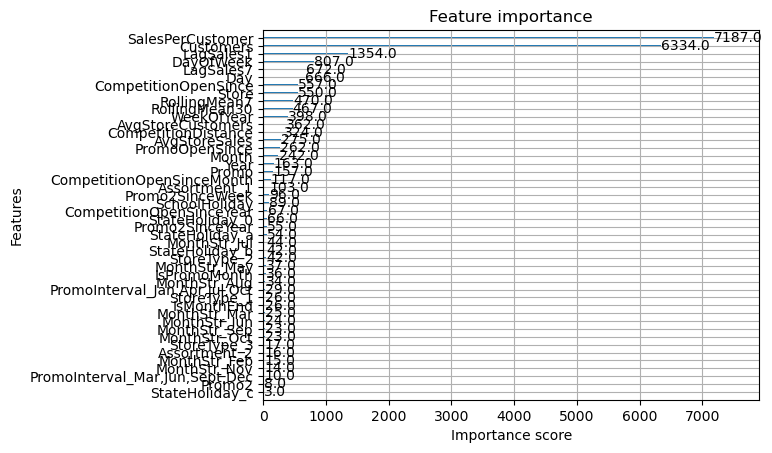

In [23]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize = (16,16))
plot_importance(xgb)
plt.show()

In [32]:
results = X_test.copy()

results['Actual_Sales'] = y_test
results['Predicted_Sales'] = preds

In [35]:
results['Error'] = (
    results['Actual_Sales']
    - results['Predicted_Sales']
)

In [36]:
results.head()

,Store,DayOfWeek,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,...,MonthStr_Jul,MonthStr_Jun,MonthStr_Mar,MonthStr_May,MonthStr_Nov,MonthStr_Oct,MonthStr_Sep,Actual_Sales,Predicted_Sales,Error
43879,59,3,496,1,0,0,2840.0,6.0,2007.0,1,...,False,False,False,False,False,True,False,8.297793,8.298157,-0.000364
562681,745,1,787,1,1,0,17650.0,11.0,2013.0,1,...,False,False,False,False,False,False,False,9.143987,9.143903,0.000084
239643,318,4,805,1,1,0,32330.0,3.0,2014.0,0,...,False,False,False,False,True,False,False,9.056839,9.054956,0.001883
689976,912,5,800,1,0,0,3100.0,5.0,2010.0,0,...,False,True,False,False,False,False,False,8.755895,8.761501,-0.005606
397240,525,5,852,1,0,0,1870.0,9.0,2013.0,0,...,False,False,False,False,True,False,False,9.306468,9.301753,0.004715


In [3]:
pbi = pd.read_csv('xg_boost.csv')

In [10]:
pbi.head()

,Store,DayOfWeek,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,...,MonthStr_Jul,MonthStr_Jun,MonthStr_Mar,MonthStr_May,MonthStr_Nov,MonthStr_Oct,MonthStr_Sep,Actual_Sales,Predicted_Sales,Error
0,59,3,496,1,0,0,2840.0,6.0,2007.0,1,...,False,False,False,False,False,True,False,4014.0,4015.463227,-0.000364
1,745,1,787,1,1,0,17650.0,11.0,2013.0,1,...,False,False,False,False,False,False,False,9357.0,9356.215164,0.000084
2,318,4,805,1,1,0,32330.0,3.0,2014.0,0,...,False,False,False,False,True,False,False,8576.0,8559.860587,0.001883
3,912,5,800,1,0,0,3100.0,5.0,2010.0,0,...,False,True,False,False,False,False,False,6347.0,6382.686304,-0.005606
4,525,5,852,1,0,0,1870.0,9.0,2013.0,0,...,False,False,False,False,True,False,False,11008.0,10956.210372,0.004715


In [7]:
pbi['Actual_Sales'] =  np.expm1(pbi['Actual_Sales'])

In [9]:
pbi['Predicted_Sales'] =  np.expm1(pbi['Predicted_Sales'])

In [ ]:
pbi.to_csv('xg_boost.csv', index = False)

### Model Evaluation

In [39]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

print(rmse)

0.017150938539620065


## Forecasting

In [46]:
import prophet as Prophet

In [43]:
daily_sales = (
    ml_model.groupby('Date')['Sales']
    .sum()
    .reset_index()
)

In [44]:
forecast_df = daily_sales[['Date', 'Sales']]
forecast_df.columns = ['ds', 'y']

In [45]:
model = Prophet()
model.fit(forecast_df)

19:26:04 - cmdstanpy - INFO - Chain [1] start processing
19:26:07 - cmdstanpy - INFO - Chain [1] done processing


In [47]:
future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

In [52]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,7770.029566,6259.112636,10114.294904,7770.029566,7770.029566,516.752757,516.752757,516.752757,1524.760801,1524.760801,1524.760801,-1008.008044,-1008.008044,-1008.008044,0.0,0.0,0.0,8286.782324
1,2013-01-02,7771.651887,6316.424821,10150.687377,7771.651887,7771.651887,425.321250,425.321250,425.321250,1345.033793,1345.033793,1345.033793,-919.712542,-919.712542,-919.712542,0.0,0.0,0.0,8196.973137
2,2013-01-03,7773.274207,5999.334480,9703.503606,7773.274207,7773.274207,57.737730,57.737730,57.737730,879.325988,879.325988,879.325988,-821.588258,-821.588258,-821.588258,0.0,0.0,0.0,7831.011937
3,2013-01-04,7774.896528,6295.297401,10092.355153,7774.896528,7774.896528,473.497640,473.497640,473.497640,1188.678938,1188.678938,1188.678938,-715.181298,-715.181298,-715.181298,0.0,0.0,0.0,8248.394168
4,2013-01-05,7776.518848,6692.375372,10391.102789,7776.518848,7776.518848,763.836596,763.836596,763.836596,1365.990336,1365.990336,1365.990336,-602.153739,-602.153739,-602.153739,0.0,0.0,0.0,8540.355445


In [53]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2013-01-01,8286.782324,6259.112636,10114.294904
1,2013-01-02,8196.973137,6316.424821,10150.687377
2,2013-01-03,7831.011937,5999.334480,9703.503606
3,2013-01-04,8248.394168,6295.297401,10092.355153
4,2013-01-05,8540.355445,6692.375372,10391.102789
...,...,...,...,...
1027,2015-10-25,538.891724,-1331.470411,2401.591649
1028,2015-10-26,9457.870472,7424.219171,11334.390863
1029,2015-10-27,9666.014734,7706.194530,11732.012790
1030,2015-10-28,9473.556546,7501.316400,11434.727740


In [56]:
forecast.to_csv('forecast_model', index = False)

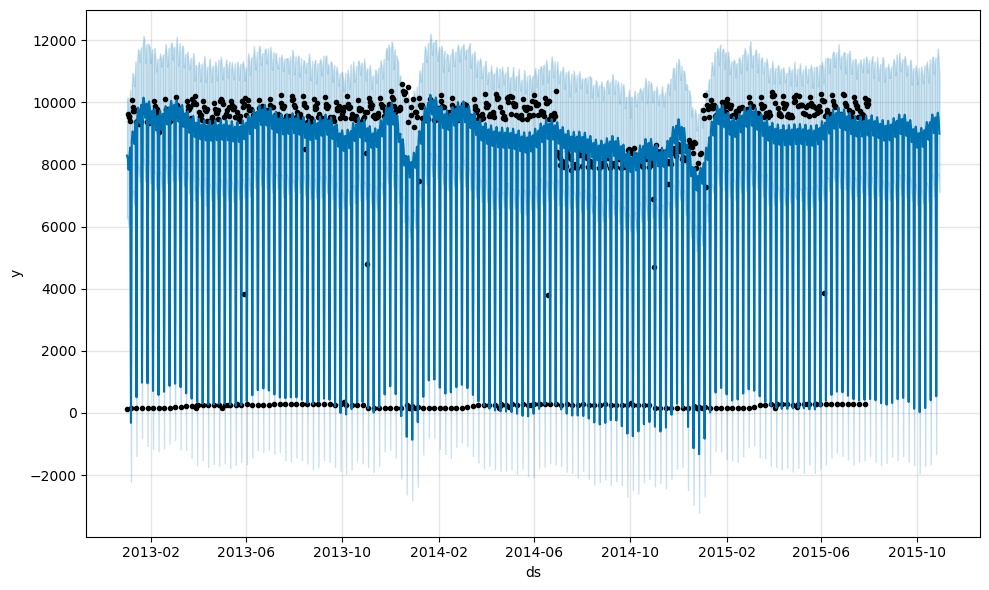

In [54]:
fig1 = model.plot(forecast)

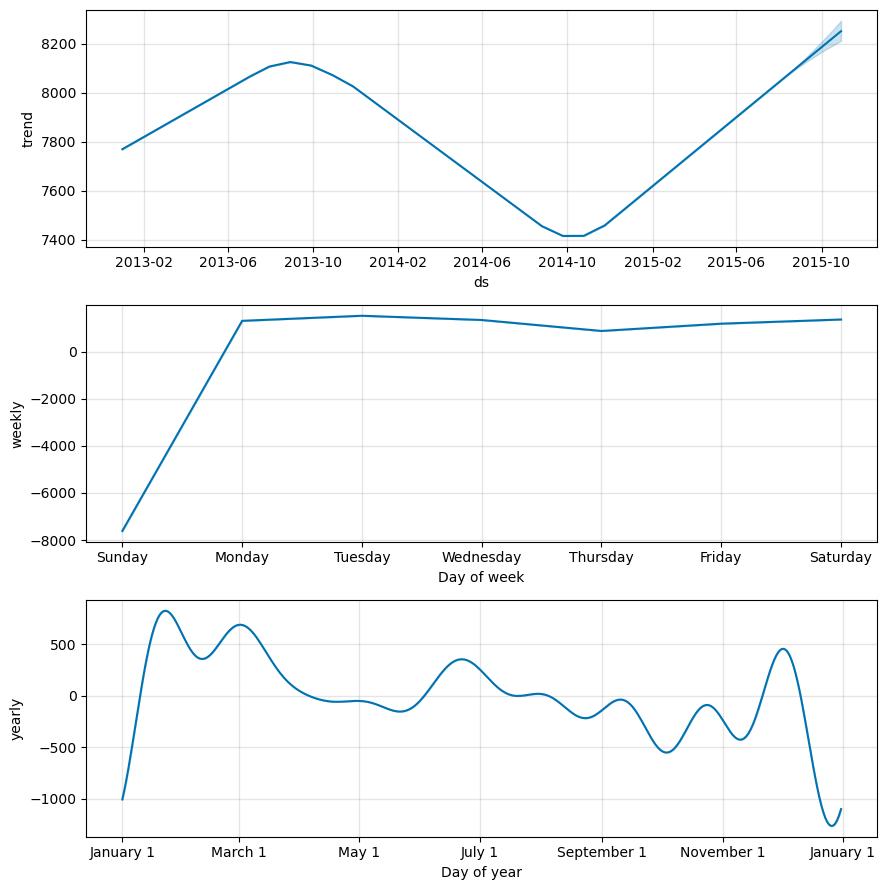

In [55]:
fig2 = model.plot_components(forecast)